In [32]:
import os
import sys
from glob import glob

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
from exactextract import exact_extract
from rasterio.merge import merge
from tqdm import tqdm

sys.path.append("../utils")

import config

In [ ]:
path = "/data/wildfire_prep/full_planet/unzipped/2019/apr/files/20190401_173755_0f32_3B_AnalyticMS_SR_clip_bandmath.tif"

In [35]:
path = os.path.join(
    "/data/wildfire_prep/full_planet/unzipped",
    "2019",
    "apr",
    "files",
    "20190401_173755_0f32_3B_AnalyticMS_SR_clip_bandmath.tif",
)

In [37]:
def import_training_geometries(year):
        """
        Function to read in buffer geometry data for a given year and convert to Albers CRS.
        """
        training_geometries = os.path.join(
            config.data_dir,
            "training_geometries",
            f"training_geometries_{year}.geojson",
        )
        return gpd.read_file(training_geometries).to_crs(config.albers_crs)
    
# Read in inspection data for 2019-2023 as separate dataframes
inspections_dict = {}
for year in range(2019, 2024):
    inspections_dict[year] = import_training_geometries(year)
    
# Unpack from dictionary
geometries_2019 = inspections_dict[2019]
geometries_2020 = inspections_dict[2020]
geometries_2021 = inspections_dict[2021]
geometries_2022 = inspections_dict[2022]
geometries_2023 = inspections_dict[2023]    

In [40]:
geometries = gpd.read_file(
    os.path.join(config.data_dir, "PUZZLE_PIECES", "inspections_master_training_geometries.geojson")
)
geometries_2019 = geometries[geometries["year"] == 2019]
geometries_2019_04 = geometries_2019[geometries_2019["month"] == 4]

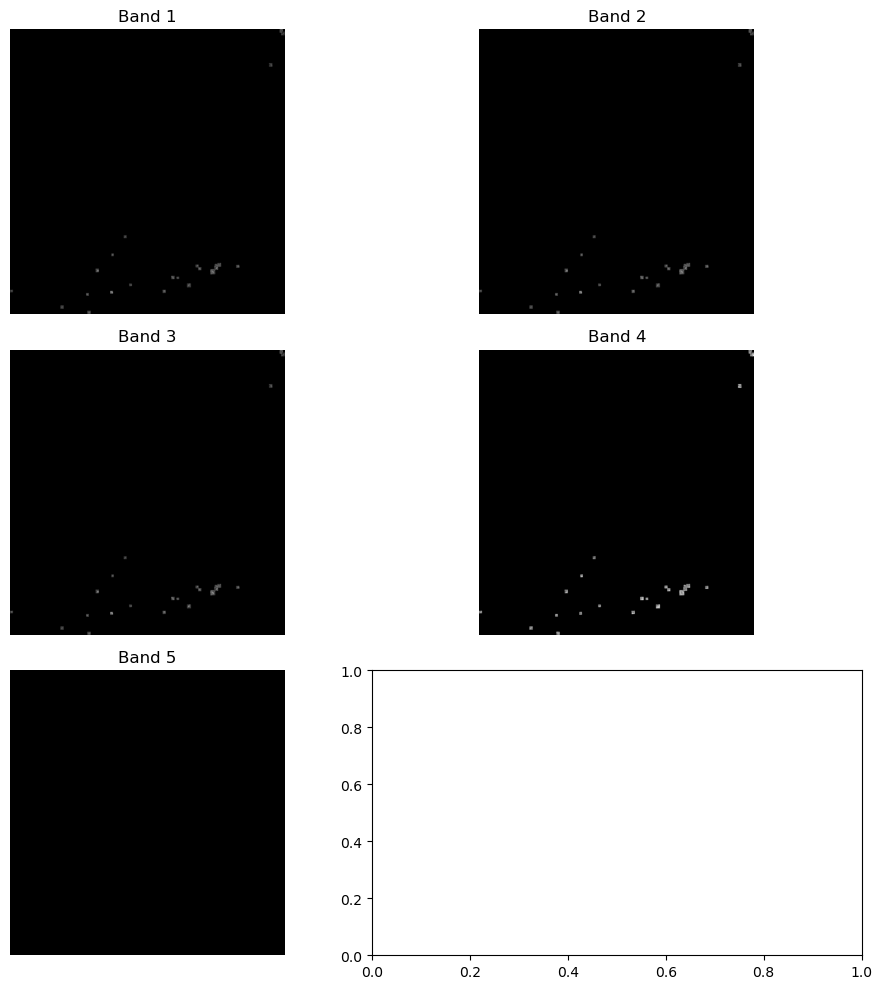

Metadata:
{'driver': 'GTiff', 'dtype': 'uint16', 'nodata': None, 'width': 2835, 'height': 2941, 'count': 5, 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 10N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-123],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32610"]]'), 'transform': Affine(3.0, 0.0, 741162.0,
       0.0, -3.0, 3825231.0)}
Data range:
Min: 0, Max: 4349
Data shape:
(5, 2941, 2835)


In [8]:
# Open path with rasterio
with rasterio.open(path) as src:
    # Read the data
    data = src.read()
    # Get the metadata
    meta = src.meta
    
# # Plot all 5 bands of data
# fig, axs = plt.subplots(3, 2, figsize=(10, 10))
# axs = axs.flatten()
# for i in range(5):
#     axs[i].imshow(data[i], cmap="gray")
#     axs[i].set_title(f"Band {i + 1}")
#     axs[i].axis("off")
# plt.tight_layout()
# plt.show()

# Print the metadata and get the range of values
print("Metadata:")
print(meta)
print("Data range:")
print(f"Min: {data.min()}, Max: {data.max()}")
# Print the shape of the data
print("Data shape:")
print(data.shape)

In [9]:
meta

{'driver': 'GTiff',
 'dtype': 'uint16',
 'nodata': None,
 'width': 2835,
 'height': 2941,
 'count': 5,
 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 10N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-123],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32610"]]'),
 'transform': Affine(3.0, 0.0, 741162.0,
        0.0, -3.0, 3825231.0)}

In [ ]:
with rasterio.open(path) as src:
    band_red = src.read(3)

with rasterio.open(path) as src:
    band_nir = src.read(4)
    
# Allow division by zero
np.seterr(divide='ignore', invalid='ignore')

# Calculate NDVI
ndvi = (band_nir.astype(float) - band_red.astype(float)) / (band_nir + band_red)

# Plot NDVI
plt.imshow(ndvi, cmap="RdYlGn")
plt.colorbar()
plt.title("NDVI")
plt.show()

In [47]:
geometries_2019_04 = geometries_2019_04.to_crs(meta["crs"])

In [49]:
# First, calculate NDVI as you did
with rasterio.open(path) as src:
    band_red = src.read(3)
    band_nir = src.read(4)
    
    # Store the metadata for later use
    ndvi_meta = src.meta.copy()
    transform = src.transform

# Calculate NDVI
ndvi_array = (band_nir.astype(float) - band_red.astype(float)) / (band_nir + band_red)

# Create a temporary NDVI raster file with proper metadata
ndvi_meta.update(
    dtype=rasterio.float32,
    count=1,
    nodata=np.nan  # or another appropriate nodata value
)

# Option 1: Create a temporary file
temp_ndvi_path = "/tmp/ndvi_temp.tif"
with rasterio.open(temp_ndvi_path, 'w', **ndvi_meta) as dst:
    dst.write(ndvi_array.astype(rasterio.float32), 1)

# Now use the file path with exact_extract
ndvi_stats = exact_extract(
    temp_ndvi_path,
    geometries_2019_04,
    ['mean', 'min', 'max'],
    include_cols=['inspection_id'],
    output="pandas",
)

# Option 2: Use MemoryFile (avoids writing to disk)
from rasterio.io import MemoryFile

with MemoryFile() as memfile:
    with memfile.open(**ndvi_meta) as dst:
        dst.write(ndvi_array.astype(rasterio.float32), 1)
    
    # Use the in-memory raster with exact_extract
    with memfile.open() as src:
        ndvi_stats = exact_extract(
            src,
            geometries_2019_04,
            ['mean', 'min', 'max'],
            include_cols=['inspection_id'],
            output="pandas",
        )
        
ndvi_stats

,inspection_id,mean,min,max
0,14191,NaN,None,None
1,14446,NaN,None,None
2,14447,NaN,None,None
3,14448,NaN,None,None
4,14449,NaN,None,None
5,14450,NaN,None,None
6,14454,NaN,None,None
7,14455,NaN,None,None
8,14456,NaN,None,None
9,14457,NaN,None,None


In [43]:
# Use exactextract to get the NDVI
ndvi_stats = exact_extract(
    ndvi,
    geometries_2019_04,
    ['mean', 'min', 'max'],
    include_cols=['inspection_id'],
    output="pandas",
    
)
ndvi_stats

Exception: Unhandled raster datatype

In [ ]:
# Open the path with xarray
import xarray as xr

dataset = xr.open_dataset(path)
dataset


<xarray.Dataset> Size: 167MB
Dimensions:      (band: 5, x: 2835, y: 2941)
Coordinates:
  * band         (band) int64 40B 1 2 3 4 5
  * x            (x) float64 23kB 7.412e+05 7.412e+05 ... 7.497e+05 7.497e+05
  * y            (y) float64 24kB 3.825e+06 3.825e+06 ... 3.816e+06 3.816e+06
    spatial_ref  int64 8B ...
Data variables:
    band_data    (band, y, x) float32 167MB ...

In [13]:
path2 = '/data/wildfire_prep/full_planet/unzipped/2019/apr/files/20190401_173755_0f32_3B_udm2_clip.tif'

In [15]:
dataset2 = xr.open_dataset(path2)
dataset2

<xarray.Dataset> Size: 267MB
Dimensions:      (band: 8, x: 2835, y: 2941)
Coordinates:
  * band         (band) int64 64B 1 2 3 4 5 6 7 8
  * x            (x) float64 23kB 7.412e+05 7.412e+05 ... 7.497e+05 7.497e+05
  * y            (y) float64 24kB 3.825e+06 3.825e+06 ... 3.816e+06 3.816e+06
    spatial_ref  int64 8B ...
Data variables:
    band_data    (band, y, x) float32 267MB ...

In [23]:
# Find the min and max values of the data
dataset2.values

<bound method Mapping.values of <xarray.Dataset> Size: 267MB
Dimensions:      (band: 8, x: 2835, y: 2941)
Coordinates:
  * band         (band) int64 64B 1 2 3 4 5 6 7 8
  * x            (x) float64 23kB 7.412e+05 7.412e+05 ... 7.497e+05 7.497e+05
  * y            (y) float64 24kB 3.825e+06 3.825e+06 ... 3.816e+06 3.816e+06
    spatial_ref  int64 8B ...
Data variables:
    band_data    (band, y, x) float32 267MB 0.0 0.0 0.0 0.0 ... 1.0 1.0 1.0 1.0>

In [26]:
# Use rasterio to read the data
with rasterio.open(path2) as src:
    data2 = src.read()
    meta2 = src.meta
data2.min()
data2.max()

np.uint8(99)